There are 170 rows and 9 columns in our dataset.
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Recency (days)             int64
Frequency (visits)         int64
Monetary ($)               int64
Spending Score (1-100)     int64
Mail id                   object
dtype: object
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Recency (days)            0
Frequency (visits)        0
Monetary ($)              0
Spending Score (1-100)    0
Mail id                   0
dtype: int64
0

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Recency (days)  \
0           1    Male   19                  15              50   
1           2    Male   21                  15               5   
2           3  Female   20                  16              90   
3           4  Female   23                  16               5   
4           5

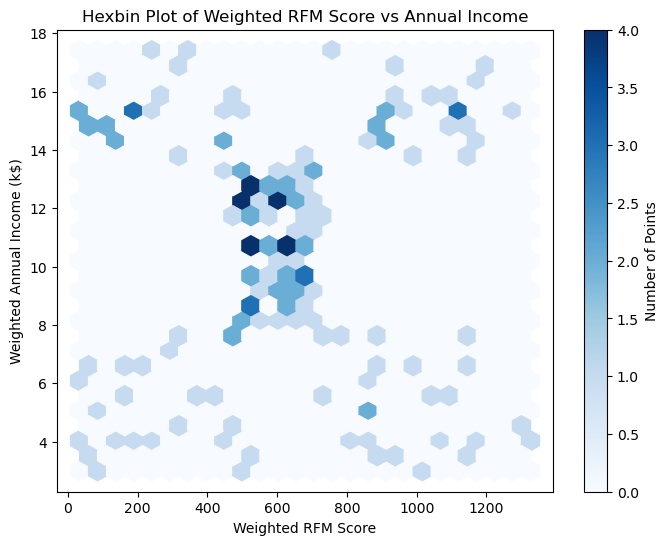

Estimated bandwidth: 0.878

Centroids (RFM Score, Income) unweighted:

Cluster 0: (RFM Score: 746, Income: $55k)
Cluster 1: (RFM Score: 1074, Income: $72k)
Cluster 2: (RFM Score: 305, Income: $76k)
Cluster 3: (RFM Score: 1043, Income: $32k)
Cluster 4: (RFM Score: 270, Income: $26k)

Average RFM per Cluster:
             Recency (days)  Frequency (visits)  Monetary ($)
MS Cluster                                                  
0                     27.0                47.0        1750.0
1                      7.0                77.0        2974.0
2                     75.0                15.0         704.0
3                      8.0                76.0        2878.0
4                     75.0                15.0         736.0


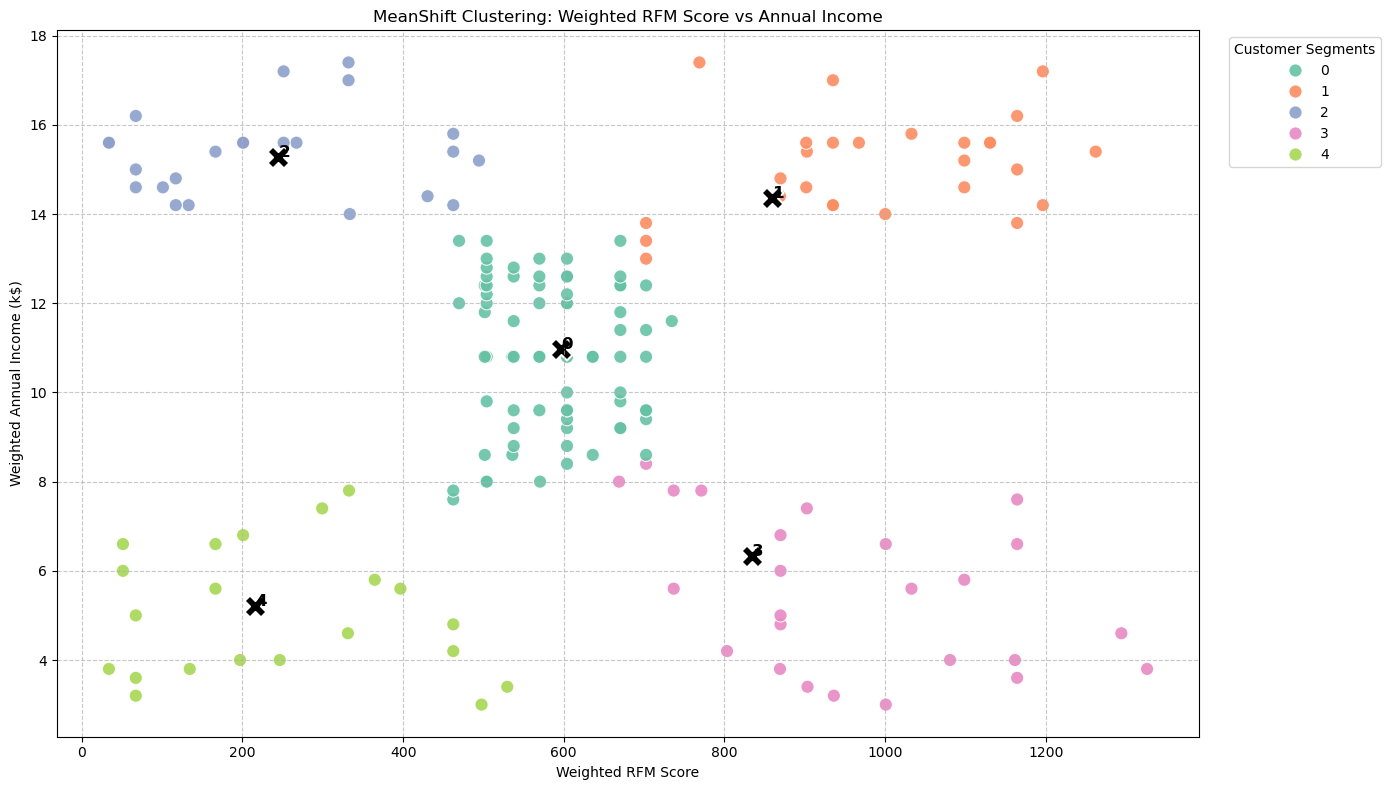


✅ Model and Scaler saved in 'model_files/'


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth

# Load dataset
df = pd.read_csv("customer_data.csv")

print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in our dataset.')
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Drop irrelevant columns
df.drop(columns=['CustomerID', 'Gender', 'Age', 'Spending Score (1-100)', 'Mail id'], 
        axis=1, inplace=True)

# Define weights
WEIGHT_RECENCY = 0.2
WEIGHT_FREQUENCY = 0.4
WEIGHT_MONETARY = 0.4
WEIGHT_INCOME = 0.2   # Weight for Annual Income
WEIGHT_RFM = 0.8      # Weight for composite RFM score

# Compute composite RFM score
df['RFM Score'] = (WEIGHT_RECENCY * (100 - df['Recency (days)'])) + \
                  (WEIGHT_FREQUENCY * df['Frequency (visits)']) + \
                  (WEIGHT_MONETARY * df['Monetary ($)'])

# Prepare data with weighted RFM Score + Income
x_rfm_income = df[['RFM Score', 'Annual Income (k$)']].copy()
x_rfm_income['RFM Score'] = x_rfm_income['RFM Score'] * WEIGHT_RFM
x_rfm_income['Annual Income (k$)'] = x_rfm_income['Annual Income (k$)'] * WEIGHT_INCOME

# Add RFM components for interpretation
x_rfm_income[['Recency (days)', 'Frequency (visits)', 'Monetary ($)']] = \
    df[['Recency (days)', 'Frequency (visits)', 'Monetary ($)']]

# Visualization of weighted data
plt.figure(figsize=(8, 6))
plt.hexbin(x_rfm_income['RFM Score'], x_rfm_income['Annual Income (k$)'], gridsize=25, cmap='Blues')
plt.colorbar(label='Number of Points')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.title('Hexbin Plot of Weighted RFM Score vs Annual Income')
plt.show()

# Standardize after weighting
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_rfm_income[['RFM Score', 'Annual Income (k$)']])

# Estimate bandwidth
bandwidth = estimate_bandwidth(x_scaled, quantile=0.15)
print(f"Estimated bandwidth: {bandwidth:.3f}")

# Mean Shift clustering
ms = MeanShift(bandwidth=bandwidth)
labels = ms.fit_predict(x_scaled)
x_rfm_income['MS Cluster'] = labels

# Calculate centroids
centroids_scaled = ms.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_unweighted = centroids_original / np.array([WEIGHT_RFM, WEIGHT_INCOME])

print("\nCentroids (RFM Score, Income) unweighted:\n")
for i, (rfm_score, income) in enumerate(centroids_unweighted):
    print(f"Cluster {i}: (RFM Score: {rfm_score:.0f}, Income: ${income:.0f}k)")

# Average RFM per cluster
cluster_rfm_means = x_rfm_income.groupby('MS Cluster')[['Recency (days)', 'Frequency (visits)', 'Monetary ($)']].mean().round(0)
print("\nAverage RFM per Cluster:\n", cluster_rfm_means)

# Visualize clusters
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=x_rfm_income,
    x='RFM Score', y='Annual Income (k$)',
    hue='MS Cluster', palette='Set2',
    s=90, edgecolor='white', alpha=0.9
)

for i, (rfm_score, income) in enumerate(centroids_original):
    plt.scatter(rfm_score, income, c='black', s=250, marker='X', edgecolor='white', linewidth=1.5)
    plt.text(rfm_score+0.5, income, str(i), fontsize=12, weight='bold')

plt.title('MeanShift Clustering: Weighted RFM Score vs Annual Income')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Customer Segments', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save model + scaler
os.makedirs("model_files", exist_ok=True)
with open("model_files/ms_model.pkl", "wb") as f:
    pickle.dump(ms, f)
with open("model_files/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nModel and Scaler saved in 'model_files/'")